# **County Propensity Score Calculation**

This notebook calculates county-level solar siting propensity scores using regression coefficients from the Capacity Intensity results table.

It creates two versions of the score:

- **Social-component score:** uses only the significant socio-political terms from the expanded model
- **Full propensity score:** uses both significant techno-economic and socio-political terms from the expanded model

Important: the social-component score is a constructed subset of the expanded model, not a separately estimated “social-only” regression.

The notebook:
- loads county-level data from the Solar-NIMBY repo
- merges techno-economic and socio-political variables by county GEOID
- computes raw predicted values using the regression coefficients
- normalizes the raw values into 0–1 propensity scores
- exports two CSV files for later backtesting / model input

In [279]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [280]:
basepath = Path("../Solar-NIMBY/data")

tech_path = basepath / "suitability_scores" / "suitability_scores_county.csv"
social_path = basepath / "county_clean" / "social_factors_merged.csv"
gdp_path = basepath / "GDP_percapita.csv"

print("Tech path exists:", tech_path.exists(), tech_path)
print("Social path exists:", social_path.exists(), social_path)
print("GDP path exists:", gdp_path.exists(), gdp_path)

Tech path exists: True ../Solar-NIMBY/data/suitability_scores/suitability_scores_county.csv
Social path exists: True ../Solar-NIMBY/data/county_clean/social_factors_merged.csv
GDP path exists: True ../Solar-NIMBY/data/GDP_percapita.csv


In [281]:
tech = pd.read_csv(tech_path, dtype=str)
social = pd.read_csv(social_path, dtype=str)
gdp = pd.read_csv(gdp_path, dtype=str)

print("tech shape:", tech.shape)
print("social shape:", social.shape)
print("gdp shape:", gdp.shape)

display(tech.head())
display(social.head())
display(gdp.head())

tech shape: (3233, 9)
social shape: (3125, 66)
gdp shape: (3041, 4)


,GHI,Protected_Land,Habitat,Slope,Population_Density,Distance_to_Substation,Land_Cover,County Name,State
0,15.0,91.54783467808332,33.74828475767056,91.02952961194357,98.63411822822329,53.24167078324826,67.86096931774522,Ballard,Kentucky
1,15.0,99.58368523026479,82.84067762929108,71.72398032689155,96.68289532515277,60.58298971632967,85.69119181280739,Bourbon,Kentucky
2,15.0,99.8961362692148,39.23642847251073,42.7597978119374,98.2395097631907,50.0,61.83963439966764,Butler,Kentucky
3,15.0,97.73388297263254,29.826520096186876,11.827321653498226,93.35279972518035,52.38005267376617,56.73794801328295,Estill,Kentucky
4,15.0,98.00082118661466,49.732293163621435,32.705892013960174,99.46684459043317,50.0,71.55528638883186,Fleming,Kentucky


,GEOID,State,County Name,area km2,area mi2,FIPS State,FIPS County,Wind Capacity Intensity (MW / 1000 sq mile),Wind Project Intensity (Projects / 1000 sq mile),Wind Avg Capacity Intensity (MW / 1000 sq mile),GDP_2017,GDP_2018,GDP_2019,GDP_2020,GDP_2021,GDP_2022,Solar MW 1000 sq mile all,Solar Projects 1000 sq mile all,Solar MW Avg 1000 sq mile all,Solar MW 1000 sq mile small,Solar Projects 1000 sq mile small,Solar MW Avg 1000 sq mile small,Solar MW 1000 sq mile medium,Solar Projects 1000 sq mile medium,Solar MW Avg 1000 sq mile medium,Solar MW 1000 sq mile large,Solar Projects 1000 sq mile large,Solar MW Avg 1000 sq mile large,No. of Private Schools,Median Income,Total Unemployment,Unemployment Rate,Hispanic/Latino,White,Black/African American,American Indian/Alaska Native,Asian,Native Hawaiian/Other Pacific Islander,Others,Number of Existing Installs,Total Installed Capacity (kW),Median Installed Capacity (kW),Total Installed Capacity (kW/ 1000 sq mile),Median Installed Capacity (kW / sq mile),Number of Existing Installs / sq mile,democrat_percentage_vote,republican_percentage_vote,green_percentage_vote,libertarian_percentage_vote,other_percentage_vote,18-24 Less than high school graduate,18-24 High school graduate,18-24 Some college or associate's degree,18-24 Bachelor's degree or higher,25+ Less than 9th grade,"25+ 9th to 12th grade, no diploma",25+ High school graduate,"25+ Some college, no degree",25+ Associate's degree,25+ Bachelor's degree,25+ Graduate or professional degree,25+ High school graduate or higher,25+ Bachelor's degree or higher,Electric Commercial Rate,Electric Industrial Rate,Electric Residential Rate
0,1001.0,Alabama,Autauga,1565.322757499382,604.3742473160263,01,001,NaN,NaN,NaN,29.49,29.91,28.96,28.82,28.91,32.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,62660,46577,2.8,0.036000340107133745,0.7071167417736587,0.19304480911487118,0.003128985630473599,0.014845676388062239,0.00037411784712184336,0.04382280418331775,12.0,227901.0,12.75,377085.89,0.02,0.02,0.27018365142239825,0.714368023046453,NaN,NaN,0.015448325531148721,9.9,33.4,45.4,11.3,2.0,8.4,32.8,19.6,9.1,16.4,11.7,89.6,28.1,0.121895086554537,0.0636515383525151,0.1350567137682845
1,1003.0,Alabama,Baldwin,4352.548564209735,1680.527705738507,01,003,NaN,NaN,NaN,29.96,31.48,33.07,32.88,35.46,36.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,64346,183804,3.7,0.05473600642024102,0.8046658929010602,0.07766852054002511,0.00557024943154116,0.008754481871879948,0.0005263907286196913,0.04628355201560188,35.0,1123484.25,14.5,668530.63,0.01,0.02,0.22409029987509005,0.7617137282433283,NaN,NaN,0.014195971881581707,14.4,39.1,38.4,8.1,2.1,6.9,27.4,21.7,9.5,20.6,11.8,91.0,32.5,0.121895086554537,0.0636515383525151,0.1350567137682845
2,1005.0,Alabama,Barbour,2342.545641813826,904.461557395602,01,005,NaN,NaN,NaN,30.83,31.33,30.87,29.61,30.27,30.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,36422,20639,8.6,0.05986599532173017,0.43951948618324543,0.46980930103476987,0.0022994885620267217,0.004083574515323316,0.0,0.023629227292550452,NaN,NaN,NaN,NaN,NaN,NaN,0.45788172656398557,0.5345122646891044,NaN,NaN,0.007606008746910059,23.2,40.3,33.1,3.5,7.4,16.9,36.7,20.5,7.3,6.7,4.4,75.7,11.2,0.121895086554537,0.0636515383525151,0.1350567137682845
3,1007.0,Alabama,Bibb,1622.295669819397,626.3716027086089,01,007,NaN,NaN,NaN,18.48,18.05,20.06,20.91,20.82,20.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54277,18333,9.7,0.03319427623020679,0.7375409321311622,0.19692280087919975,0.0017494280715919794,0.0011662853810613196,0.0004037141703673799,0.027631992105145112,0.0,305.0,18.75,486.93,0.03,0.0,0.20698280354351226,0.7842626367899947,NaN,NaN,0.008754559666492965,14.1,64.3,20.1,1.6,6.2,13.3,43.9,18.0,6.7,7.9,4.0,80.5,11.9,0.121895086554537,0.0636515383525151,0.1350567137682845
4,1009.0,Alabama,Blount,1685.0980704349663,650.6197351910813,01,009,NaN,NaN,NaN,16.6,17.59,17.05,15.24,17.23,17.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,52830,46871,6.0

,state,county,GDPpercapita,Population Estimate
0,Texas,Loving,120097.35,51
1,Texas,McMullen,1960.16,576
2,Texas,Glasscock,1861.93,1164
3,Texas,Martin,1337.95,5217
4,Texas,Upton,1251.21,3152


In [282]:
def clean_str_col(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

def pad_str(series, width):
    return clean_str_col(series).str.zfill(width)

def ensure_geoid_county(df, name):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    # Existing GEOID
    if "GEOID" in df.columns:
        df["GEOID"] = (
            clean_str_col(df["GEOID"])
            .str.replace("US", "", regex=False)
            .str.zfill(5)
            .str[:5]
        )
        return df

    # Other county ID columns
    for c in ["FIPS", "fips", "CountyFIPS", "COUNTY_FIPS", "county_fips", "GeoFIPS", "GEOIDFQ"]:
        if c in df.columns:
            df["GEOID"] = (
                clean_str_col(df[c])
                .str.replace("US", "", regex=False)
                .str.zfill(5)
                .str[:5]
            )
            return df

    # Build from state/county code columns
    state_candidates = ["STATEFP", "statefp", "State", "STATE", "FIPS State"]
    county_candidates = ["COUNTYFP", "countyfp", "County", "COUNTY", "FIPS County"]

    state_col = next((c for c in state_candidates if c in df.columns), None)
    county_col = next((c for c in county_candidates if c in df.columns), None)

    if state_col is not None and county_col is not None:
        df["GEOID"] = pad_str(df[state_col], 2) + pad_str(df[county_col], 3)
        return df

    # Allow name-based merge later
    if "County Name" in df.columns and "State" in df.columns:
        return df

    raise KeyError(f"[{name}] Could not construct county GEOID. Columns: {list(df.columns)}")

def minmax_scale(series):
    s = pd.to_numeric(series, errors="coerce")
    return (s - s.min()) / (s.max() - s.min())

In [283]:
tech = ensure_geoid_county(tech, "tech")
social = ensure_geoid_county(social, "social")

# DO NOT run ensure_geoid_county on GDP file
gdp = gdp.copy()
gdp.columns = [c.strip() for c in gdp.columns]

print("tech GEOID present:", "GEOID" in tech.columns)
print("social GEOID present:", "GEOID" in social.columns)
print("gdp GEOID present:", "GEOID" in gdp.columns)

if "GEOID" in social.columns:
    display(social[["GEOID"]].head())
display(gdp.head())

tech GEOID present: False
social GEOID present: True
gdp GEOID present: False


,GEOID
0,01001
1,01003
2,01005
3,01007
4,01009


,state,county,GDPpercapita,Population Estimate
0,Texas,Loving,120097.35,51
1,Texas,McMullen,1960.16,576
2,Texas,Glasscock,1861.93,1164
3,Texas,Martin,1337.95,5217
4,Texas,Upton,1251.21,3152


In [284]:
# Rename GDP columns
gdp = gdp.rename(columns={
    "state": "State",
    "county": "County Name",
    "GDPpercapita": "GDP_per_Capita"
})

# Clean county/state names to merge onto social
gdp["State"] = gdp["State"].astype(str).str.strip().str.lower()
gdp["County Name"] = gdp["County Name"].astype(str).str.strip().str.lower()

social["State"] = social["State"].astype(str).str.strip().str.lower()
social["County Name"] = social["County Name"].astype(str).str.strip().str.lower()

# Keep only the GDP columns needed
gdp_small = gdp[["State", "County Name", "GDP_per_Capita"]].copy()
gdp_small["GDP_per_Capita"] = pd.to_numeric(gdp_small["GDP_per_Capita"], errors="coerce")

# Merge GDP onto social by county/state
social = social.merge(
    gdp_small,
    on=["State", "County Name"],
    how="left"
)

print("GDP merge missing rate:", social["GDP_per_Capita"].isna().mean())
display(social[["GEOID", "County Name", "State", "GDP_per_Capita"]].head())

GDP merge missing rate: 0.02464


,GEOID,County Name,State,GDP_per_Capita
0,01001,autauga,alabama,28.91
1,01003,baldwin,alabama,35.46
2,01005,barbour,alabama,30.27
3,01007,bibb,alabama,20.82
4,01009,blount,alabama,17.23


In [285]:
# GDP coverage checks

# Total counties in social table
n_total = len(social)

# How many missing GDP_per_Capita
n_missing = social["GDP_per_Capita"].isna().sum()
missing_pct = n_missing / n_total * 100

print(f"Total counties in social: {n_total}")
print(f"Missing GDP_per_Capita: {n_missing} ({missing_pct:.2f}%)")

# List missing counties (keep GEOID + names)
missing_gdp = social.loc[social["GDP_per_Capita"].isna(), ["GEOID", "County Name", "State"]].drop_duplicates()

print("\nSample missing GDP counties:")
display(missing_gdp.head(20))

missing_gdp.to_csv("missing_gdp_per_capita_counties.csv", index=False)
print("\nSaved missing list to: missing_gdp_per_capita_counties.csv")

Total counties in social: 3125
Missing GDP_per_Capita: 77 (2.46%)

Sample missing GDP counties:


,GEOID,County Name,State
277,09001,fairfield,connecticut
278,09003,hartford,connecticut
279,09005,litchfield,connecticut
280,09007,middlesex,connecticut
281,09009,new haven,connecticut
282,09011,new london,connecticut
283,09013,tolland,connecticut
284,09015,windham,connecticut
2780,51003,albemarle,virginia
2781,51005,alleghany,virginia



Saved missing list to: missing_gdp_per_capita_counties.csv


In [286]:
# Tech has no GEOID in the source file, so attach it using county/state names from social
tech["County Name"] = tech["County Name"].astype(str).str.strip().str.lower()
tech["State"] = tech["State"].astype(str).str.strip().str.lower()

geo_lookup = social[["GEOID", "County Name", "State"]].drop_duplicates()

tech_with_geoid = tech.merge(
    geo_lookup,
    on=["County Name", "State"],
    how="left"
)

print("Tech rows:", len(tech_with_geoid))
print("Missing GEOID in tech after merge:", tech_with_geoid["GEOID"].isna().sum())

display(tech_with_geoid.head())

Tech rows: 3240
Missing GEOID in tech after merge: 140


,GHI,Protected_Land,Habitat,Slope,Population_Density,Distance_to_Substation,Land_Cover,County Name,State,GEOID
0,15.0,91.54783467808332,33.74828475767056,91.02952961194357,98.63411822822329,53.24167078324826,67.86096931774522,ballard,kentucky,21007
1,15.0,99.58368523026479,82.84067762929108,71.72398032689155,96.68289532515277,60.58298971632967,85.69119181280739,bourbon,kentucky,21017
2,15.0,99.8961362692148,39.23642847251073,42.7597978119374,98.2395097631907,50.0,61.83963439966764,butler,kentucky,21031
3,15.0,97.73388297263254,29.826520096186876,11.827321653498226,93.35279972518035,52.38005267376617,56.73794801328295,estill,kentucky,21065
4,15.0,98.00082118661466,49.732293163621435,32.705892013960174,99.46684459043317,50.0,71.55528638883186,fleming,kentucky,21069


In [287]:
# Techno-economic factors
TECH_COLS = {
    "GHI": "GHI",
    "Protected_Land": "Protected_Land",          
    "Slope": "Slope",
    "Population_Sparsity": "Population_Density" # closest processed county variable available
}

# Socio-political factors
SOCIO_COLS = {
    "Black": "Black/African American",
    "Asian": "Asian",
    "Income": "Median Income",
    "Grad_Education": "25+ Graduate or professional degree",
    "GDP_per_Capita": "GDP_per_Capita"
}

print("Techno-economic columns used:")
for k, v in TECH_COLS.items():
    print(f"  {k} -> {v}")

print("\nSocio-political columns used:")
for k, v in SOCIO_COLS.items():
    print(f"  {k} -> {v}")

Techno-economic columns used:
  GHI -> GHI
  Protected_Land -> Protected_Land
  Slope -> Slope
  Population_Sparsity -> Population_Density

Socio-political columns used:
  Black -> Black/African American
  Asian -> Asian
  Income -> Median Income
  Grad_Education -> 25+ Graduate or professional degree
  GDP_per_Capita -> GDP_per_Capita


In [288]:
tech_small = tech_with_geoid[["GEOID", "County Name", "State"] + list(TECH_COLS.values())].copy()
social_small = social[["GEOID", "County Name", "State"] + list(SOCIO_COLS.values())].copy()

df = social_small.merge(
    tech_small[["GEOID"] + list(TECH_COLS.values())],
    on="GEOID",
    how="left"
)

print("Merged rows:", len(df))
display(df.head())

Merged rows: 6600


,GEOID,County Name,State,Black/African American,Asian,Median Income,25+ Graduate or professional degree,GDP_per_Capita,GHI,Protected_Land,Slope,Population_Density
0,01001,autauga,alabama,0.19304480911487118,0.014845676388062239,62660,11.7,28.91,20.0,99.31800456799064,57.42490669043507,92.08957718232968
1,01003,baldwin,alabama,0.07766852054002511,0.008754481871879948,64346,11.8,35.46,20.0,88.6415074642447,91.48385952846611,81.16025930465071
2,01005,barbour,alabama,0.46980930103476987,0.004083574515323316,36422,4.4,30.27,20.0,94.05199818346958,66.47511731759008,98.44771798365123
3,01007,bibb,alabama,0.19692280087919975,0.0011662853810613196,54277,4.0,20.82,19.89209880495092,88.98087387964148,40.41824050362783,95.74890631668801
4,01009,blount,alabama,0.013968275442215985,0.002942469645212568,52830,5.6,17.23,15.0,99.79058964561325,38.62243700207288,92.47346469868386


In [289]:
df = df.rename(columns={
    "Black/African American": "Black",
    "Asian": "Asian",
    "Median Income": "Income",
    "25+ Graduate or professional degree": "Grad_Education",
    "GDP_per_Capita": "GDP_per_Capita",
    "GHI": "GHI",
    "Protected_Land": "Protected_Land",
    "Slope": "Slope",
    "Population_Density": "Population_Sparsity"
})

display(df.head())

,GEOID,County Name,State,Black,Asian,Income,Grad_Education,GDP_per_Capita,GHI,Protected_Land,Slope,Population_Sparsity
0,01001,autauga,alabama,0.19304480911487118,0.014845676388062239,62660,11.7,28.91,20.0,99.31800456799064,57.42490669043507,92.08957718232968
1,01003,baldwin,alabama,0.07766852054002511,0.008754481871879948,64346,11.8,35.46,20.0,88.6415074642447,91.48385952846611,81.16025930465071
2,01005,barbour,alabama,0.46980930103476987,0.004083574515323316,36422,4.4,30.27,20.0,94.05199818346958,66.47511731759008,98.44771798365123
3,01007,bibb,alabama,0.19692280087919975,0.0011662853810613196,54277,4.0,20.82,19.89209880495092,88.98087387964148,40.41824050362783,95.74890631668801
4,01009,blount,alabama,0.013968275442215985,0.002942469645212568,52830,5.6,17.23,15.0,99.79058964561325,38.62243700207288,92.47346469868386


In [290]:
numeric_cols = [
    "Black", "Asian", "Income", "Grad_Education", "GDP_per_Capita",
    "GHI", "Protected_Land", "Slope", "Population_Sparsity"
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

display(df[numeric_cols].describe())
print(df[numeric_cols].isna().mean().sort_values())

,Black,Asian,Income,Grad_Education,GDP_per_Capita,GHI,Protected_Land,Slope,Population_Sparsity
count,3940.000000,3940.000000,3939.000000,3940.000000,4021.000000,3475.000000,3475.000000,3475.000000,3475.000000
mean,0.071729,0.011755,57613.240416,7.568452,80.264743,17.935045,89.839317,70.408737,89.314897
std,0.128602,0.023145,14101.556165,4.393099,1894.289116,17.490629,14.129431,29.658574,18.542680
min,0.000000,0.000000,17109.000000,0.000000,10.270000,4.765299,2.379858,0.138137,10.000000
25%,0.004540,0.002587,49070.000000,5.000000,31.350000,5.000000,87.750973,49.527457,89.578167
50%,0.015694,0.004929,54664.000000,6.400000,43.300000,15.000000,95.840881,81.732457,97.320935
75%,0.063455,0.011915,63785.000000,8.700000,57.020000,20.000000,98.558283,96.087746,99.206502
max,0.871264,0.389100,156821.000000,49.100000,120097.350000,90.000000,100.000000,100.000000,100.000000


GDP_per_Capita         0.390758
Black                  0.403030
Asian                  0.403030
Grad_Education         0.403030
Income                 0.403182
GHI                    0.473485
Protected_Land         0.473485
Slope                  0.473485
Population_Sparsity    0.473485
dtype: float64


In [291]:
# Normalize SOCIO-POLITICAL variables to 1–100 BEFORE weighted sum

SOCIAL_VARS = ["Black", "Asian", "Income", "Grad_Education", "GDP_per_Capita"]

def normalize_1_100(s):
    s = pd.to_numeric(s, errors="coerce")
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.nan, index=s.index)
    # scale to [1, 100]
    return 1 + 99 * (s - mn) / (mx - mn)

df_norm = df.copy()

# Normalize social vars
for v in SOCIAL_VARS:
    df_norm[v] = normalize_1_100(df_norm[v])

TECH_VARS = ["GHI", "Protected_Land", "Slope", "Population_Sparsity"]
for v in TECH_VARS:
    df_norm[v] = normalize_1_100(df_norm[v])

display(df_norm[SOCIAL_VARS].describe())

,Black,Asian,Income,Grad_Education,GDP_per_Capita
count,3940.000000,3940.000000,3939.000000,3940.000000,4021.000000
mean,9.150416,3.990975,29.701327,16.260218,1.057704
std,14.612809,5.888957,9.992370,8.857777,1.561655
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.515832,1.658294,23.647582,11.081466,1.017378
50%,2.783324,2.254042,27.611494,13.904277,1.027230
75%,8.210234,4.031583,34.074639,18.541752,1.038541
max,100.000000,100.000000,100.000000,100.000000,100.000000


In [292]:
CONST = -52.397

# Socio-political-only coefficients
B_SOCIAL = {
    "Black": 0.877,
    "Asian": 0.449,
    "Income": 0.459,
    "Grad_Education": -0.495,
    "GDP_per_Capita": 0.810,
}

# Full model = techno-economic + socio-political
B_FULL = {
    "GHI": 0.902,
    "Protected_Land": 0.287,
    "Slope": 0.226,
    "Population_Sparsity": 0.191,
    "Black": 0.877,
    "Asian": 0.449,
    "Income": 0.459,
    "Grad_Education": -0.495,
    "GDP_per_Capita": 0.810,
}

In [293]:
# Compute raw scores using normalized social variables (df_norm) 

def weighted_sum(frame, coef_dict, const=0.0):
    out = pd.Series(const, index=frame.index, dtype=float)
    for var, beta in coef_dict.items():
        out = out + beta * frame[var]
    return out

df_norm["propensity_social_raw"] = weighted_sum(df_norm, B_SOCIAL, const=CONST)
df_norm["propensity_full_raw"] = weighted_sum(df_norm, B_FULL, const=CONST)

# Normalize raw scores to [0, 1] for propensity score
df_norm["social_score"] = minmax_scale(df_norm["propensity_social_raw"])
df_norm["full_score"]   = minmax_scale(df_norm["propensity_full_raw"])

display(df_norm[["propensity_social_raw", "social_score", "propensity_full_raw", "full_score"]].describe())

,propensity_social_raw,social_score,propensity_full_raw,full_score
count,3040.000000,3040.000000,3040.000000,3040.000000
mean,-35.050366,0.293033,38.317765,0.400635
std,13.766291,0.144922,25.508486,0.171552
min,-62.885795,0.000000,-21.253720,0.000000
25%,-43.570780,0.203336,21.523224,0.287687
50%,-39.774078,0.243305,33.661275,0.369319
75%,-31.734264,0.327943,50.565955,0.483008
max,32.105020,1.000000,127.438787,1.000000


In [294]:
# Exports using normalized-score version 

df_norm["county_name"] = (
    df_norm["County Name"].astype(str).str.strip().str.title() + ", " +
    df_norm["State"].astype(str).str.strip().str.title()
)

social_out = df_norm[["county_name", "social_score"]].copy().rename(columns={"social_score": "score"})
full_out   = df_norm[["county_name", "full_score"]].copy().rename(columns={"full_score": "score"})

social_out = social_out.sort_values("score", ascending=False).reset_index(drop=True)
full_out   = full_out.sort_values("score", ascending=False).reset_index(drop=True)

social_out.to_csv("county_propensity_scores_social_only.csv", index=False)
full_out.to_csv("county_propensity_scores_full.csv", index=False)

print("Saved updated scores with normalized social factors:")
print(" - county_propensity_scores_social_only.csv")
print(" - county_propensity_scores_full.csv")

Saved updated scores with normalized social factors:
 - county_propensity_scores_social_only.csv
 - county_propensity_scores_full.csv


In [295]:
# Cost modifier based on propensity score 
# cost_modifier = 1 + (1 - propensity_score)

df_norm["cost_modifier_full"] = 1 + (1 - df_norm["full_score"])
df_norm["cost_modifier_social"] = 1 + (1 - df_norm["social_score"])

display(df_norm[["full_score", "cost_modifier_full", "social_score", "cost_modifier_social"]].describe())

examples = df_norm[["county_name", "full_score", "cost_modifier_full"]].copy()
display(examples.sort_values("full_score", ascending=False).head(5))  # high propensity => ~1.0-1.1
display(examples.sort_values("full_score", ascending=True).head(5))   # low propensity => up to ~2.0

,full_score,cost_modifier_full,social_score,cost_modifier_social
count,3040.000000,3040.000000,3040.000000,3040.000000
mean,0.400635,1.599365,0.293033,1.706967
std,0.171552,0.171552,0.144922,0.144922
min,0.000000,1.000000,0.000000,1.000000
25%,0.287687,1.516992,0.203336,1.672057
50%,0.369319,1.630681,0.243305,1.756695
75%,0.483008,1.712313,0.327943,1.796664
max,1.000000,2.000000,1.000000,2.000000


,county_name,full_score,cost_modifier_full
2729,"Winkler, Texas",1.000000,1.000000
2646,"Midland, Texas",0.991066,1.008934
2483,"Andrews, Texas",0.987152,1.012848
2719,"Ward, Texas",0.982946,1.017054
2732,"Yoakum, Texas",0.978040,1.021960


,county_name,full_score,cost_modifier_full
2939,"San Juan, Washington",0.000000,2.000000
2927,"Jefferson, Washington",0.008567,1.991433
554,"Shoshone, Idaho",0.049109,1.950891
1589,"Mineral, Montana",0.056544,1.943456
1585,"Lincoln, Montana",0.063748,1.936252


In [296]:
# Normalize raw scores to [0, 1] for propensity score
df_norm["social_score"] = minmax_scale(df_norm["propensity_social_raw"])
df_norm["full_score"]   = minmax_scale(df_norm["propensity_full_raw"])

display(df_norm[[
    "GEOID", "County Name", "State",
    "social_score", "full_score"
]].head())

display(df_norm[[
    "propensity_social_raw", "social_score",
    "propensity_full_raw", "full_score"
]].describe())

,GEOID,County Name,State,social_score,full_score
0,01001,autauga,alabama,0.386063,0.476849
1,01003,baldwin,alabama,0.262468,0.412870
2,01005,barbour,alabama,0.650336,0.657991
3,01007,bibb,alabama,0.425823,0.460800
4,01009,blount,alabama,0.214237,0.304986


,propensity_social_raw,social_score,propensity_full_raw,full_score
count,3040.000000,3040.000000,3040.000000,3040.000000
mean,-35.050366,0.293033,38.317765,0.400635
std,13.766291,0.144922,25.508486,0.171552
min,-62.885795,0.000000,-21.253720,0.000000
25%,-43.570780,0.203336,21.523224,0.287687
50%,-39.774078,0.243305,33.661275,0.369319
75%,-31.734264,0.327943,50.565955,0.483008
max,32.105020,1.000000,127.438787,1.000000


In [297]:
df_norm["county_name"] = (
    df_norm["County Name"].astype(str).str.strip().str.title() + ", " +
    df_norm["State"].astype(str).str.strip().str.title()
)

social_out = df_norm[["county_name", "social_score"]].copy()
social_out = social_out.rename(columns={"social_score": "score"})
social_out = social_out.sort_values("score", ascending=False).reset_index(drop=True)

full_out = df_norm[["county_name", "full_score"]].copy()
full_out = full_out.rename(columns={"full_score": "score"})
full_out = full_out.sort_values("score", ascending=False).reset_index(drop=True)

display(social_out.head(10))
display(full_out.head(10))

social_out.to_csv("county_propensity_scores_social_only.csv", index=False)
full_out.to_csv("county_propensity_scores_full.csv", index=False)
print("Saved both CSVs.")

,county_name,score
0,"Holmes, Mississippi",1.000000
1,"Jefferson, Mississippi",0.982321
2,"Greene, Alabama",0.974806
3,"Tunica, Mississippi",0.969994
4,"Claiborne, Mississippi",0.960124
5,"Clayton, Georgia",0.958923
6,"Macon, Alabama",0.936056
7,"Coahoma, Mississippi",0.919550
8,"Noxubee, Mississippi",0.914245
9,"Humphreys, Mississippi",0.902070


,county_name,score
0,"Winkler, Texas",1.000000
1,"Midland, Texas",0.991066
2,"Andrews, Texas",0.987152
3,"Ward, Texas",0.982946
4,"Yoakum, Texas",0.978040
5,"Ector, Texas",0.973320
6,"Crane, Texas",0.969527
7,"Glasscock, Texas",0.961901
8,"Gaines, Texas",0.960882
9,"Reeves, Texas",0.960455


Saved both CSVs.


In [298]:
social_csv = "county_propensity_scores_social_only.csv"
full_csv = "county_propensity_scores_full.csv"

social_out.to_csv(social_csv, index=False)
full_out.to_csv(full_csv, index=False)

print(f"Saved: {social_csv}")
print(f"Saved: {full_csv}")

Saved: county_propensity_scores_social_only.csv
Saved: county_propensity_scores_full.csv


In [299]:
print("Top 10 counties by social-only score")
display(social_out.head(10))

print("Bottom 10 counties by social-only score")
display(social_out.tail(10))

print("Top 10 counties by full score")
display(full_out.head(10))

print("Bottom 10 counties by full score")
display(full_out.tail(10))

Top 10 counties by social-only score


,county_name,score
0,"Holmes, Mississippi",1.000000
1,"Jefferson, Mississippi",0.982321
2,"Greene, Alabama",0.974806
3,"Tunica, Mississippi",0.969994
4,"Claiborne, Mississippi",0.960124
5,"Clayton, Georgia",0.958923
6,"Macon, Alabama",0.936056
7,"Coahoma, Mississippi",0.919550
8,"Noxubee, Mississippi",0.914245
9,"Humphreys, Mississippi",0.902070


Bottom 10 counties by social-only score


,county_name,score
6590,"Hamilton, Kansas",NaN
6591,"Hamilton, Kansas",NaN
6592,"Hamilton, Kansas",NaN
6593,"Hamilton, Kansas",NaN
6594,"Hamilton, Kansas",NaN
6595,"Hamilton, Kansas",NaN
6596,"Hamilton, Kansas",NaN
6597,"Hamilton, Kansas",NaN
6598,"Hamilton, Kansas",NaN
6599,"Hamilton, Kansas",NaN


Top 10 counties by full score


,county_name,score
0,"Winkler, Texas",1.000000
1,"Midland, Texas",0.991066
2,"Andrews, Texas",0.987152
3,"Ward, Texas",0.982946
4,"Yoakum, Texas",0.978040
5,"Ector, Texas",0.973320
6,"Crane, Texas",0.969527
7,"Glasscock, Texas",0.961901
8,"Gaines, Texas",0.960882
9,"Reeves, Texas",0.960455


Bottom 10 counties by full score


,county_name,score
6590,"Hamilton, Kansas",NaN
6591,"Hamilton, Kansas",NaN
6592,"Hamilton, Kansas",NaN
6593,"Hamilton, Kansas",NaN
6594,"Hamilton, Kansas",NaN
6595,"Hamilton, Kansas",NaN
6596,"Hamilton, Kansas",NaN
6597,"Hamilton, Kansas",NaN
6598,"Hamilton, Kansas",NaN
6599,"Hamilton, Kansas",NaN


In [300]:
print("df columns contain:", [c for c in df.columns if "score" in c or "propensity" in c or "county_name" in c])
print("df_norm columns contain:", [c for c in df_norm.columns if "score" in c or "propensity" in c or "county_name" in c])

df columns contain: []
df_norm columns contain: ['propensity_social_raw', 'propensity_full_raw', 'social_score', 'full_score', 'county_name']


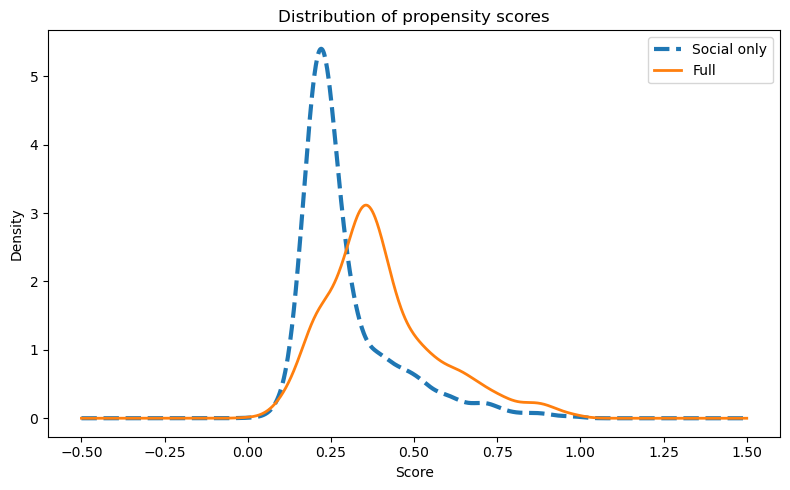

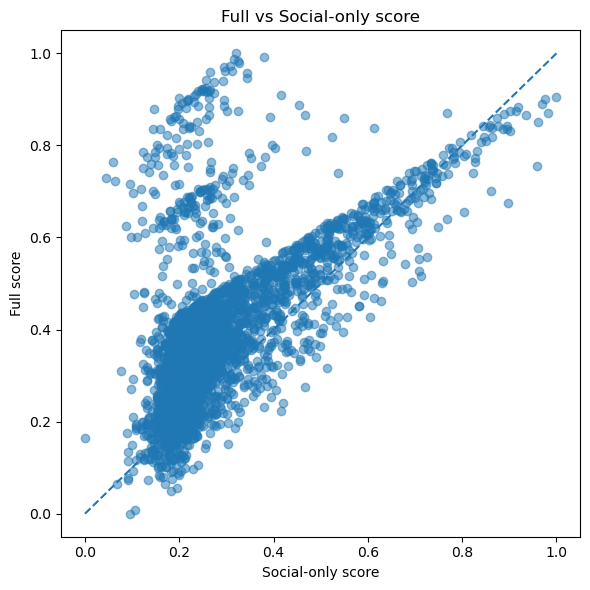

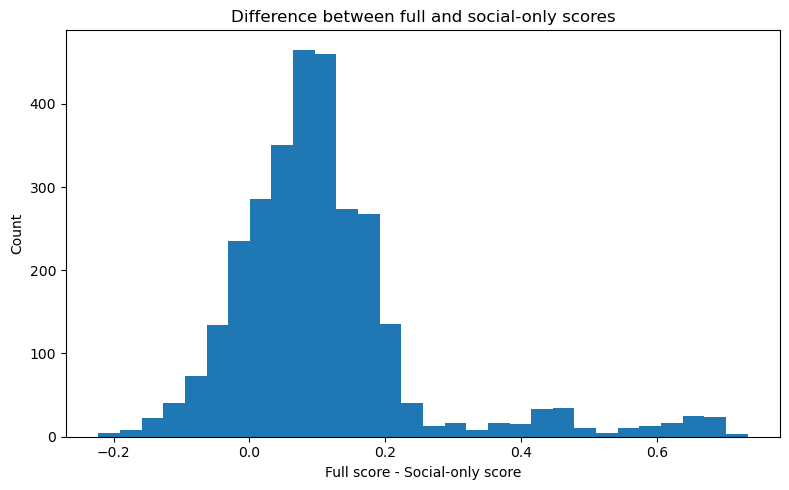

Top 10 counties where full score is MUCH HIGHER than social-only:


,county_name,social_score,full_score,diff,abs_diff
1762,"De Baca, New Mexico",0.145831,0.879166,0.733334,0.733334
1778,"Roosevelt, New Mexico",0.198578,0.902610,0.704032,0.704032
1767,"Harding, New Mexico",0.059651,0.763096,0.703445,0.703445
2676,"Reeves, Texas",0.264473,0.960455,0.695982,0.695982
1776,"Quay, New Mexico",0.143669,0.836638,0.692969,0.692969
2634,"Lynn, Texas",0.198154,0.886364,0.688210,0.688210
2521,"Cochran, Texas",0.205659,0.891711,0.686052,0.686052
2603,"Jeff Davis, Texas",0.043669,0.728918,0.685249,0.685249
1769,"Lea, New Mexico",0.257627,0.941637,0.684010,0.684010
1766,"Guadalupe, New Mexico",0.197427,0.879698,0.682272,0.682272


Top 10 counties where full score is LOWER than social-only:


,county_name,social_score,full_score,diff,abs_diff
1169,"Prince Georges, Maryland",0.897261,0.674726,-0.222535,0.222535
386,"Clayton, Georgia",0.958923,0.755608,-0.203315,0.203315
192,"San Francisco, California",0.713775,0.517174,-0.196600,0.196600
2928,"King, Washington",0.513466,0.317246,-0.196219,0.196219
1750,"Passaic, New Jersey",0.414811,0.222602,-0.192209,0.192209
2942,"Snohomish, Washington",0.466168,0.276235,-0.189932,0.189932
1829,"Queens, New York",0.693065,0.503519,-0.189546,0.189546
403,"Douglas, Georgia",0.708819,0.526629,-0.182190,0.182190
1748,"Morris, New Jersey",0.419755,0.240591,-0.179165,0.179165
1741,"Essex, New Jersey",0.604812,0.426866,-0.177946,0.177946


In [301]:
import matplotlib.pyplot as plt

compare = df_norm[["county_name", "social_score", "full_score"]].copy()
compare["diff"] = compare["full_score"] - compare["social_score"]
compare["abs_diff"] = compare["diff"].abs()

# KDE-style line plot using pandas
fig, ax = plt.subplots(figsize=(8, 5))
compare["social_score"].plot(kind="kde", ax=ax, label="Social only", linestyle="--", linewidth=3)
compare["full_score"].plot(kind="kde", ax=ax, label="Full", linewidth=2)
ax.set_title("Distribution of propensity scores")
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(compare["social_score"], compare["full_score"], alpha=0.5)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Full vs Social-only score")
ax.set_xlabel("Social-only score")
ax.set_ylabel("Full score")
plt.tight_layout()
plt.show()

# Difference histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(compare["diff"].dropna(), bins=30)
ax.set_title("Difference between full and social-only scores")
ax.set_xlabel("Full score - Social-only score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Counties with largest positive / negative change
print("Top 10 counties where full score is MUCH HIGHER than social-only:")
display(compare.sort_values("diff", ascending=False).head(10))

print("Top 10 counties where full score is LOWER than social-only:")
display(compare.sort_values("diff", ascending=True).head(10))

In [302]:
df_norm[["Black","Asian","Income","Grad_Education","GDP_per_Capita"]].agg(["min","max"]).T

,min,max
Black,1.0,100.0
Asian,1.0,100.0
Income,1.0,100.0
Grad_Education,1.0,100.0
GDP_per_Capita,1.0,100.0


In [303]:
df_norm["cost_modifier_full"] = 1 + (1 - df_norm["full_score"])

df_norm["cost_modifier_social"] = 1 + (1 - df_norm["social_score"])

df_norm[["full_score","cost_modifier_full"]].describe()

,full_score,cost_modifier_full
count,3040.000000,3040.000000
mean,0.400635,1.599365
std,0.171552,0.171552
min,0.000000,1.000000
25%,0.287687,1.516992
50%,0.369319,1.630681
75%,0.483008,1.712313
max,1.000000,2.000000


In [304]:
cost_mod_out = df_norm[["county_name", "full_score", "cost_modifier_full"]].copy()
cost_mod_out.to_csv("county_cost_modifier_full.csv", index=False)

In [305]:
cm = pd.read_csv("county_cost_modifier_full.csv")

cm["check"] = (2 - cm["full_score"]) - cm["cost_modifier_full"]

print("Max absolute error:", cm["check"].abs().max())
print("Mean absolute error:", cm["check"].abs().mean())

cm.head()

Max absolute error: 4.440892098500626e-16
Mean absolute error: 5.60224381504931e-17


,county_name,full_score,cost_modifier_full,check
0,"Autauga, Alabama",0.476849,1.523151,0.000000e+00
1,"Baldwin, Alabama",0.412870,1.587130,2.220446e-16
2,"Barbour, Alabama",0.657991,1.342009,0.000000e+00
3,"Bibb, Alabama",0.460800,1.539200,0.000000e+00
4,"Blount, Alabama",0.304986,1.695014,0.000000e+00


In [306]:
cm.sort_values("full_score", ascending=False).head(5)

,county_name,full_score,cost_modifier_full,check
2729,"Winkler, Texas",1.000000,1.000000,0.000000e+00
2646,"Midland, Texas",0.991066,1.008934,0.000000e+00
2483,"Andrews, Texas",0.987152,1.012848,0.000000e+00
2719,"Ward, Texas",0.982946,1.017054,0.000000e+00
2732,"Yoakum, Texas",0.978040,1.021960,-2.220446e-16


In [307]:
cm.sort_values("full_score", ascending=True).head(5)

,county_name,full_score,cost_modifier_full,check
2939,"San Juan, Washington",0.000000,2.000000,0.000000e+00
2927,"Jefferson, Washington",0.008567,1.991433,-2.220446e-16
554,"Shoshone, Idaho",0.049109,1.950891,-2.220446e-16
1589,"Mineral, Montana",0.056544,1.943456,0.000000e+00
1585,"Lincoln, Montana",0.063748,1.936252,0.000000e+00


In [308]:
missing = pd.read_csv("missing_gdp_per_capita_counties.csv")
print("Missing GDP counties:", len(missing))
print("Example missing:", missing.head(10))

Missing GDP counties: 77
Example missing:      GEOID County Name        State
0   9001.0   fairfield  connecticut
1   9003.0    hartford  connecticut
2   9005.0  litchfield  connecticut
3   9007.0   middlesex  connecticut
4   9009.0   new haven  connecticut
5   9011.0  new london  connecticut
6   9013.0     tolland  connecticut
7   9015.0     windham  connecticut
8  51003.0   albemarle     virginia
9  51005.0   alleghany     virginia


In [309]:
SOCIAL_VARS = ["Black", "Asian", "Income", "Grad_Education", "GDP_per_Capita"]  

df_norm[SOCIAL_VARS].describe()

,Black,Asian,Income,Grad_Education,GDP_per_Capita
count,3940.000000,3940.000000,3939.000000,3940.000000,4021.000000
mean,9.150416,3.990975,29.701327,16.260218,1.057704
std,14.612809,5.888957,9.992370,8.857777,1.561655
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.515832,1.658294,23.647582,11.081466,1.017378
50%,2.783324,2.254042,27.611494,13.904277,1.027230
75%,8.210234,4.031583,34.074639,18.541752,1.038541
max,100.000000,100.000000,100.000000,100.000000,100.000000


In [310]:
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("scipy not available; t-test / Wilcoxon / KS / Spearman tests will be skipped.")

gdp_orig_path = Path("../Solar-NIMBY/data/GDP_percapita.csv")
gdp_filled_path = Path("data/processed/GDP_percapita_merged.csv")

scenario_dir = Path("data/processed/score_scenarios")
scenario_dir.mkdir(parents=True, exist_ok=True)

print("tech_path:", tech_path)
print("social_path:", social_path)
print("gdp_orig_path exists:", gdp_orig_path.exists(), gdp_orig_path)
print("gdp_filled_path exists:", gdp_filled_path.exists(), gdp_filled_path)

TECH_COLS_LOCAL = {
    "GHI": "GHI",
    "Protected_Land": "Protected_Land",
    "Slope": "Slope",
    "Population_Sparsity": "Population_Density",
}

SOCIO_COLS_LOCAL = {
    "Black": "Black/African American",
    "Asian": "Asian",
    "Income": "Median Income",
    "Grad_Education": "25+ Graduate or professional degree",
    "GDP_per_Capita": "GDP_per_Capita",
}

B_SOCIAL_LOCAL = {
    "Black": 0.877,
    "Asian": 0.449,
    "Income": 0.459,
    "Grad_Education": -0.495,
    "GDP_per_Capita": 0.810,
}

B_FULL_LOCAL = {
    "GHI": 0.902,
    "Protected_Land": 0.287,
    "Slope": 0.226,
    "Population_Sparsity": 0.191,
    "Black": 0.877,
    "Asian": 0.449,
    "Income": 0.459,
    "Grad_Education": -0.495,
    "GDP_per_Capita": 0.810,
}

CONST_LOCAL = -52.397

def normalize_1_100_local(s):
    s = pd.to_numeric(s, errors="coerce")
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.nan, index=s.index)
    return 1 + 99 * (s - mn) / (mx - mn)

def weighted_sum_local(frame, coef_dict, const=0.0):
    out = pd.Series(const, index=frame.index, dtype=float)
    for var, beta in coef_dict.items():
        out = out + beta * frame[var]
    return out

def minmax_scale_local(series):
    s = pd.to_numeric(series, errors="coerce")
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.nan, index=s.index)
    return (s - mn) / (mx - mn)

def load_and_merge_base(gdp_file):
    tech_raw = pd.read_csv(tech_path, dtype=str)
    social_raw = pd.read_csv(social_path, dtype=str)
    gdp_raw = pd.read_csv(gdp_file, dtype=str)

    tech_raw = ensure_geoid_county(tech_raw, "tech_raw")
    social_raw = ensure_geoid_county(social_raw, "social_raw")

    # clean social names
    social_raw["State"] = social_raw["State"].astype(str).str.strip().str.lower()
    social_raw["County Name"] = social_raw["County Name"].astype(str).str.strip().str.lower()

    # clean tech names and attach GEOID from social lookup
    tech_raw["State"] = tech_raw["State"].astype(str).str.strip().str.lower()
    tech_raw["County Name"] = tech_raw["County Name"].astype(str).str.strip().str.lower()

    geo_lookup = social_raw[["GEOID", "County Name", "State"]].drop_duplicates()
    tech_with_geoid_local = tech_raw.merge(
        geo_lookup,
        on=["County Name", "State"],
        how="left"
    )

    # clean GDP file
    gdp_raw = gdp_raw.rename(columns={
        "state": "State",
        "county": "County Name",
        "GDPpercapita": "GDP_per_Capita"
    })

    needed_gdp_cols = {"State", "County Name", "GDP_per_Capita"}
    missing_needed = needed_gdp_cols - set(gdp_raw.columns)
    if missing_needed:
        raise ValueError(f"{gdp_file} missing GDP columns: {missing_needed}")

    gdp_raw["State"] = gdp_raw["State"].astype(str).str.strip().str.lower()
    gdp_raw["County Name"] = gdp_raw["County Name"].astype(str).str.strip().str.lower()
    gdp_raw["GDP_per_Capita"] = pd.to_numeric(gdp_raw["GDP_per_Capita"], errors="coerce")

    gdp_small_local = gdp_raw[["State", "County Name", "GDP_per_Capita"]].drop_duplicates().copy()

    social_with_gdp = social_raw.merge(
        gdp_small_local,
        on=["State", "County Name"],
        how="left"
    )

    social_small_local = social_with_gdp[
        ["GEOID", "County Name", "State"] + list(SOCIO_COLS_LOCAL.values())
    ].copy()

    tech_small_local = tech_with_geoid_local[
        ["GEOID"] + list(TECH_COLS_LOCAL.values())
    ].copy()

    df_local = social_small_local.merge(
        tech_small_local,
        on="GEOID",
        how="left"
    )

    df_local = df_local.rename(columns={
        "Black/African American": "Black",
        "Asian": "Asian",
        "Median Income": "Income",
        "25+ Graduate or professional degree": "Grad_Education",
        "GDP_per_Capita": "GDP_per_Capita",
        "GHI": "GHI",
        "Protected_Land": "Protected_Land",
        "Slope": "Slope",
        "Population_Density": "Population_Sparsity"
    })

    numeric_cols_local = [
        "Black", "Asian", "Income", "Grad_Education", "GDP_per_Capita",
        "GHI", "Protected_Land", "Slope", "Population_Sparsity"
    ]
    for c in numeric_cols_local:
        df_local[c] = pd.to_numeric(df_local[c], errors="coerce")

    df_local["gdp_available"] = df_local["GDP_per_Capita"].notna()

    return df_local

def build_score_scenario(
    scenario_name,
    gdp_file,
    include_gdp=True,
    restrict_to_nonmissing_gdp=False
):
    """
    include_gdp=True  -> score uses GDP_per_Capita coefficient
    include_gdp=False -> drop GDP_per_Capita from the score
    restrict_to_nonmissing_gdp=True -> keep only counties with GDP available in the chosen GDP file
    """
    df_local = load_and_merge_base(gdp_file).copy()

    if restrict_to_nonmissing_gdp:
        df_local = df_local[df_local["gdp_available"]].copy()

    social_vars = ["Black", "Asian", "Income", "Grad_Education"]
    if include_gdp:
        social_vars = social_vars + ["GDP_per_Capita"]

    tech_vars = ["GHI", "Protected_Land", "Slope", "Population_Sparsity"]
    full_vars = tech_vars + social_vars

    df_local = df_local.dropna(subset=full_vars).copy()

    df_norm_local = df_local.copy()
    for v in full_vars:
        df_norm_local[v] = normalize_1_100_local(df_norm_local[v])

    b_social = B_SOCIAL_LOCAL.copy()
    b_full = B_FULL_LOCAL.copy()

    if not include_gdp:
        b_social.pop("GDP_per_Capita", None)
        b_full.pop("GDP_per_Capita", None)

    df_norm_local["propensity_social_raw"] = weighted_sum_local(df_norm_local, b_social, const=CONST_LOCAL)
    df_norm_local["propensity_full_raw"] = weighted_sum_local(df_norm_local, b_full, const=CONST_LOCAL)

    df_norm_local["social_score"] = minmax_scale_local(df_norm_local["propensity_social_raw"])
    df_norm_local["full_score"] = minmax_scale_local(df_norm_local["propensity_full_raw"])

    df_norm_local["county_name"] = (
        df_norm_local["County Name"].astype(str).str.strip().str.title() + ", " +
        df_norm_local["State"].astype(str).str.strip().str.title()
    )

    df_norm_local["scenario"] = scenario_name
    df_norm_local["gdp_source"] = Path(gdp_file).name
    df_norm_local["include_gdp"] = include_gdp
    df_norm_local["restrict_to_nonmissing_gdp"] = restrict_to_nonmissing_gdp

    return df_norm_local

def export_scenario_scores(df_scenario, stem):
    social_out_local = (
        df_scenario[["GEOID", "county_name", "social_score"]]
        .rename(columns={"social_score": "score"})
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )
    full_out_local = (
        df_scenario[["GEOID", "county_name", "full_score"]]
        .rename(columns={"full_score": "score"})
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

    social_path_local = scenario_dir / f"{stem}_social.csv"
    full_path_local = scenario_dir / f"{stem}_full.csv"

    social_out_local.to_csv(social_path_local, index=False)
    full_out_local.to_csv(full_path_local, index=False)

    return social_path_local, full_path_local

def compare_two_score_frames(left_df, right_df, score_col):
    merged = left_df[["GEOID", "county_name", score_col]].merge(
        right_df[["GEOID", "county_name", score_col]],
        on=["GEOID", "county_name"],
        how="inner",
        suffixes=("_left", "_right")
    ).copy()

    merged["diff"] = merged[f"{score_col}_right"] - merged[f"{score_col}_left"]
    merged["abs_diff"] = merged["diff"].abs()
    merged["sq_diff"] = merged["diff"] ** 2

    out = {
        "n_common_counties": len(merged),
        "mean_left": merged[f"{score_col}_left"].mean(),
        "mean_right": merged[f"{score_col}_right"].mean(),
        "mean_diff_right_minus_left": merged["diff"].mean(),
        "median_diff_right_minus_left": merged["diff"].median(),
        "mae": merged["abs_diff"].mean(),
        "rmse": np.sqrt(merged["sq_diff"].mean()),
        "max_abs_diff": merged["abs_diff"].max(),
        "pearson_r": merged[f"{score_col}_left"].corr(merged[f"{score_col}_right"], method="pearson"),
        "spearman_r": merged[f"{score_col}_left"].corr(merged[f"{score_col}_right"], method="spearman"),
    }

    return pd.Series(out), merged

def paired_score_tests(df_scenario, left_col="social_score", right_col="full_score"):
    tmp = df_scenario[["GEOID", "county_name", left_col, right_col]].dropna().copy()
    diff = tmp[right_col] - tmp[left_col]

    results = {
        "n": len(tmp),
        "mean_left": tmp[left_col].mean(),
        "mean_right": tmp[right_col].mean(),
        "mean_diff_right_minus_left": diff.mean(),
        "median_diff_right_minus_left": diff.median(),
        "pearson_r": tmp[left_col].corr(tmp[right_col], method="pearson"),
        "spearman_r": tmp[left_col].corr(tmp[right_col], method="spearman"),
    }

    if SCIPY_AVAILABLE and len(tmp) > 1:
        t_res = stats.ttest_rel(tmp[right_col], tmp[left_col], nan_policy="omit")
        results["paired_t_stat"] = t_res.statistic
        results["paired_t_pvalue"] = t_res.pvalue

        try:
            w_res = stats.wilcoxon(tmp[right_col], tmp[left_col])
            results["wilcoxon_stat"] = w_res.statistic
            results["wilcoxon_pvalue"] = w_res.pvalue
        except Exception:
            results["wilcoxon_stat"] = np.nan
            results["wilcoxon_pvalue"] = np.nan

        ks_res = stats.ks_2samp(tmp[right_col], tmp[left_col])
        results["ks_stat"] = ks_res.statistic
        results["ks_pvalue"] = ks_res.pvalue
    else:
        results["paired_t_stat"] = np.nan
        results["paired_t_pvalue"] = np.nan
        results["wilcoxon_stat"] = np.nan
        results["wilcoxon_pvalue"] = np.nan
        results["ks_stat"] = np.nan
        results["ks_pvalue"] = np.nan

    return pd.Series(results)

def centered_piecewise_cost_modifier(score_series):
    """
    Maps:
      min(score)  -> 0.5
      mean(score) -> 1.0
      max(score)  -> 1.5
    using a piecewise linear transform centered at the mean.
    """
    s = pd.to_numeric(score_series, errors="coerce")
    mn, mu, mx = s.min(), s.mean(), s.max()

    out = pd.Series(np.nan, index=s.index, dtype=float)

    lower = s <= mu
    upper = s >= mu

    if mu > mn:
        out.loc[lower] = 1.0 + 0.5 * (s.loc[lower] - mu) / (mu - mn)
    else:
        out.loc[lower] = 1.0

    if mx > mu:
        out.loc[upper] = 1.0 + 0.5 * (s.loc[upper] - mu) / (mx - mu)
    else:
        out.loc[upper] = 1.0

    return out.clip(lower=0.5, upper=1.5)

tech_path: ../Solar-NIMBY/data/suitability_scores/suitability_scores_county.csv
social_path: ../Solar-NIMBY/data/county_clean/social_factors_merged.csv
gdp_orig_path exists: True ../Solar-NIMBY/data/GDP_percapita.csv
gdp_filled_path exists: True data/processed/GDP_percapita_merged.csv


In [311]:
scenarios = {}

# Original GDP file, GDP included in score, only counties with GDP in original file
scenarios["orig_with_gdp"] = build_score_scenario(
    scenario_name="orig_with_gdp",
    gdp_file=gdp_orig_path,
    include_gdp=True,
    restrict_to_nonmissing_gdp=True
)

# Filled GDP file, GDP included in score, counties with GDP in filled file
scenarios["filled_with_gdp"] = build_score_scenario(
    scenario_name="filled_with_gdp",
    gdp_file=gdp_filled_path,
    include_gdp=True,
    restrict_to_nonmissing_gdp=True
)

# Original GDP file, GDP DROPPED from score, but restrict to original GDP-covered counties
scenarios["orig_no_gdp_same_sample"] = build_score_scenario(
    scenario_name="orig_no_gdp_same_sample",
    gdp_file=gdp_orig_path,
    include_gdp=False,
    restrict_to_nonmissing_gdp=True
)

# Filled GDP file, GDP DROPPED from score, allow all counties that can be scored without GDP
scenarios["filled_no_gdp_all_counties"] = build_score_scenario(
    scenario_name="filled_no_gdp_all_counties",
    gdp_file=gdp_filled_path,
    include_gdp=False,
    restrict_to_nonmissing_gdp=False
)

# Filled GDP file, GDP DROPPED from score, but keep only counties with GDP in filled file
scenarios["filled_no_gdp_gdp_sample"] = build_score_scenario(
    scenario_name="filled_no_gdp_gdp_sample",
    gdp_file=gdp_filled_path,
    include_gdp=False,
    restrict_to_nonmissing_gdp=True
)

# Quick summary
scenario_summary = []
for name, sdf in scenarios.items():
    scenario_summary.append({
        "scenario": name,
        "n_counties": len(sdf),
        "n_unique_geoid": sdf["GEOID"].nunique(),
        "mean_social_score": sdf["social_score"].mean(),
        "mean_full_score": sdf["full_score"].mean(),
        "gdp_source": sdf["gdp_source"].iloc[0],
        "include_gdp": sdf["include_gdp"].iloc[0],
        "restrict_to_nonmissing_gdp": sdf["restrict_to_nonmissing_gdp"].iloc[0],
    })

scenario_summary = pd.DataFrame(scenario_summary).sort_values("scenario").reset_index(drop=True)
display(scenario_summary)

# Export score CSVs for the main extra scenarios
exports = {}
exports["filled_with_gdp"] = export_scenario_scores(scenarios["filled_with_gdp"], "filled_with_gdp")
exports["filled_no_gdp_all_counties"] = export_scenario_scores(scenarios["filled_no_gdp_all_counties"], "filled_no_gdp_all_counties")
exports["filled_no_gdp_gdp_sample"] = export_scenario_scores(scenarios["filled_no_gdp_gdp_sample"], "filled_no_gdp_gdp_sample")

print("Saved scenario score CSVs to:")
for name, (social_p, full_p) in exports.items():
    print(f" - {name}")
    print(f"    social: {social_p}")
    print(f"    full:   {full_p}")

,scenario,n_counties,n_unique_geoid,mean_social_score,mean_full_score,gdp_source,include_gdp,restrict_to_nonmissing_gdp
0,filled_no_gdp_all_counties,3189,3099,0.293183,0.399056,GDP_percapita_merged.csv,False,False
1,filled_no_gdp_gdp_sample,3187,3097,0.293038,0.399028,GDP_percapita_merged.csv,False,True
2,filled_with_gdp,3187,3097,0.194838,0.319765,GDP_percapita_merged.csv,True,True
3,orig_no_gdp_same_sample,3040,3040,0.310099,0.406100,GDP_percapita.csv,False,True
4,orig_with_gdp,3040,3040,0.291102,0.281997,GDP_percapita.csv,True,True


Saved scenario score CSVs to:
 - filled_with_gdp
    social: data/processed/score_scenarios/filled_with_gdp_social.csv
    full:   data/processed/score_scenarios/filled_with_gdp_full.csv
 - filled_no_gdp_all_counties
    social: data/processed/score_scenarios/filled_no_gdp_all_counties_social.csv
    full:   data/processed/score_scenarios/filled_no_gdp_all_counties_full.csv
 - filled_no_gdp_gdp_sample
    social: data/processed/score_scenarios/filled_no_gdp_gdp_sample_social.csv
    full:   data/processed/score_scenarios/filled_no_gdp_gdp_sample_full.csv


In [312]:
comparison_rows = []

# A) With GDP in the score:
# original GDP-covered counties vs filled GDP-covered counties
for score_col in ["social_score", "full_score"]:
    stats_row, merged_scores = compare_two_score_frames(
        scenarios["orig_with_gdp"],
        scenarios["filled_with_gdp"],
        score_col=score_col
    )
    comparison_rows.append({
        "comparison": "orig_with_gdp_vs_filled_with_gdp",
        "score_type": score_col,
        **stats_row.to_dict()
    })

# B) Drop GDP from the score:
# original GDP sample vs all counties after adding back missing counties
# This captures how much scores move just because the scoring sample changes
for score_col in ["social_score", "full_score"]:
    stats_row, merged_scores = compare_two_score_frames(
        scenarios["orig_no_gdp_same_sample"],
        scenarios["filled_no_gdp_all_counties"],
        score_col=score_col
    )
    comparison_rows.append({
        "comparison": "orig_no_gdp_same_sample_vs_filled_no_gdp_all_counties",
        "score_type": score_col,
        **stats_row.to_dict()
    })

# C) Same counties with GDP available, but drop GDP from the score
# This isolates the effect of removing GDP from the propensity score formula
for score_col in ["social_score", "full_score"]:
    stats_row, merged_scores = compare_two_score_frames(
        scenarios["filled_with_gdp"],
        scenarios["filled_no_gdp_gdp_sample"],
        score_col=score_col
    )
    comparison_rows.append({
        "comparison": "filled_with_gdp_vs_filled_no_gdp_gdp_sample",
        "score_type": score_col,
        **stats_row.to_dict()
    })

comparison_summary = pd.DataFrame(comparison_rows)
display(comparison_summary)

# Paired tests: full vs social-only within each scenario
test_rows = []
for name in [
    "filled_with_gdp",
    "filled_no_gdp_all_counties",
    "filled_no_gdp_gdp_sample",
]:
    out = paired_score_tests(scenarios[name], left_col="social_score", right_col="full_score")
    test_rows.append({
        "scenario": name,
        **out.to_dict()
    })

paired_test_summary = pd.DataFrame(test_rows)
display(paired_test_summary)

print("Interpretation guide:")
print("- pearson_r / spearman_r near 1 => very similar rankings / values")
print("- paired_t_pvalue small => average full vs social-only scores differ")
print("- wilcoxon_pvalue small => median paired difference differs from 0")
print("- ks_pvalue small => overall score distributions differ")

,comparison,score_type,n_common_counties,mean_left,mean_right,mean_diff_right_minus_left,median_diff_right_minus_left,mae,rmse,max_abs_diff,pearson_r,spearman_r
0,orig_with_gdp_vs_filled_with_gdp,social_score,3040.0,0.291102,0.184245,-0.106857,-0.093565,0.106857,0.117290,0.824426,0.976120,0.984423
1,orig_with_gdp_vs_filled_with_gdp,full_score,3040.0,0.281997,0.312708,0.030710,0.027896,0.031833,0.036605,0.317771,0.993426,0.997952
2,orig_no_gdp_same_sample_vs_filled_no_gdp_all_c...,social_score,3040.0,0.310099,0.293460,-0.016640,-0.018898,0.017123,0.018283,0.030327,0.999093,0.997806
3,orig_no_gdp_same_sample_vs_filled_no_gdp_all_c...,full_score,3040.0,0.406100,0.401043,-0.005058,-0.005857,0.005928,0.006717,0.026698,0.999747,0.999592
4,filled_with_gdp_vs_filled_no_gdp_gdp_sample,social_score,4447.0,0.242817,0.276175,0.033359,0.077029,0.116129,0.135708,0.435942,0.452932,0.526529
5,filled_with_gdp_vs_filled_no_gdp_gdp_sample,full_score,4447.0,0.360473,0.391557,0.031084,0.070190,0.113222,0.145210,0.726643,0.599170,0.604861


,scenario,n,mean_left,mean_right,mean_diff_right_minus_left,median_diff_right_minus_left,pearson_r,spearman_r,paired_t_stat,paired_t_pvalue,wilcoxon_stat,wilcoxon_pvalue,ks_stat,ks_pvalue
0,filled_with_gdp,3097.0,0.189918,0.315589,0.125672,0.114121,0.623966,0.622801,65.022559,0.000000e+00,68589.0,0.0,0.538586,0.000000e+00
1,filled_no_gdp_all_counties,3099.0,0.294916,0.399822,0.104906,0.087022,0.610686,0.611350,41.133925,1.688516e-295,456250.0,0.0,0.412714,1.252309e-236
2,filled_no_gdp_gdp_sample,3097.0,0.294768,0.399794,0.105027,0.087035,0.610521,0.611458,41.178072,5.663489e-296,453228.0,0.0,0.412980,8.619099e-237


Interpretation guide:
- pearson_r / spearman_r near 1 => very similar rankings / values
- paired_t_pvalue small => average full vs social-only scores differ
- wilcoxon_pvalue small => median paired difference differs from 0
- ks_pvalue small => overall score distributions differ


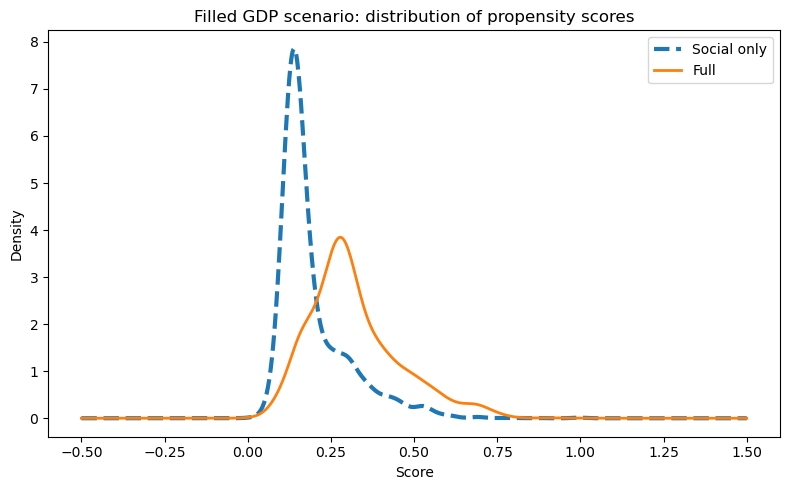

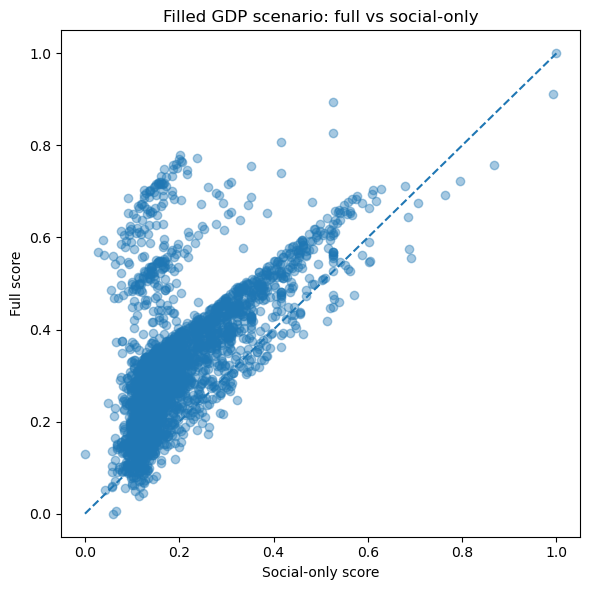

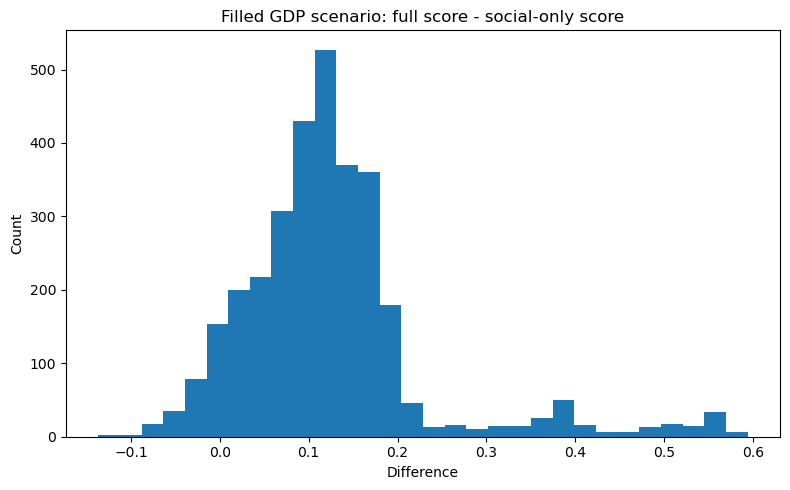

Top 10 counties where full score is much higher than social-only (filled GDP scenario):


,county_name,social_score,full_score,diff,abs_diff
1762,"De Baca, New Mexico",0.092060,0.685935,0.593875,0.593875
2676,"Reeves, Texas",0.166571,0.749427,0.582855,0.582855
2729,"Winkler, Texas",0.200973,0.780226,0.579254,0.579254
1778,"Roosevelt, New Mexico",0.125052,0.704155,0.579103,0.579103
1769,"Lea, New Mexico",0.162075,0.734590,0.572515,0.572515
2483,"Andrews, Texas",0.199122,0.770138,0.571016,0.571016
2533,"Crane, Texas",0.186061,0.756430,0.570369,0.570369
2634,"Lynn, Texas",0.124805,0.691502,0.566697,0.566697
2521,"Cochran, Texas",0.129625,0.695763,0.566138,0.566138
2549,"Ector, Texas",0.193650,0.759341,0.565691,0.565691


Top 10 counties where full score is lower than social-only (filled GDP scenario):


,county_name,social_score,full_score,diff,abs_diff
277,"Fairfield, Connecticut",0.692224,0.555619,-0.136605,0.136605
278,"Hartford, Connecticut",0.688251,0.575936,-0.112315,0.112315
2807,"Fairfax, Virginia",0.867518,0.758181,-0.109337,0.109337
2895,"Martinsville City, Virginia",0.570478,0.475292,-0.095187,0.095187
281,"New Haven, Connecticut",0.512308,0.418654,-0.093654,0.093654
1750,"Passaic, New Jersey",0.260549,0.173847,-0.086702,0.086702
2882,"Emporia City, Virginia",0.992266,0.910856,-0.081410,0.081410
2877,"Charlottesville City, Virginia",0.539088,0.459619,-0.079469,0.079469
1589,"Mineral, Montana",0.123342,0.044441,-0.078902,0.078902
6494,"Hamilton, Kansas",0.526286,0.449084,-0.077202,0.077202


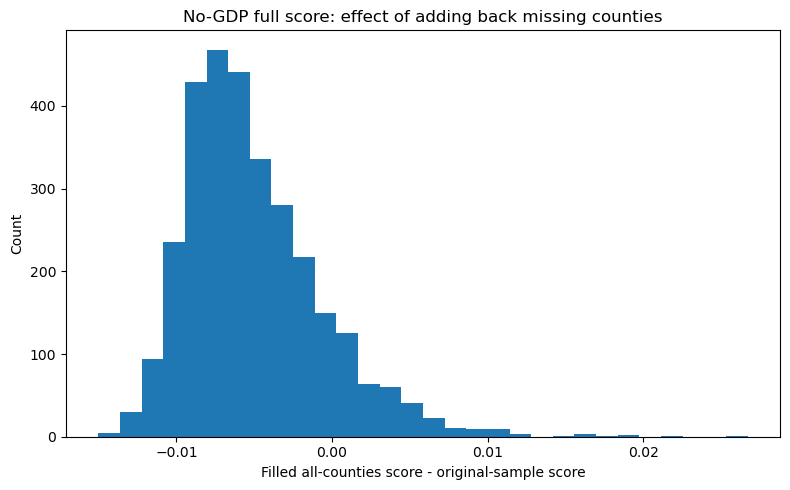

Top 10 counties with biggest change after adding back missing counties (no-GDP full score):


,GEOID,county_name,full_score_left,full_score_right,diff,abs_diff,sq_diff
1763,35028,"Los Alamos, New Mexico",0.454468,0.481166,0.026698,0.026698,0.000713
2774,51013,"Arlington, Virginia",0.270655,0.291920,0.021265,0.021265,0.000452
197,06085,"Santa Clara, California",0.849942,0.868905,0.018964,0.018964,0.000360
280,11001,"District Of Columbia, District Of Columbia",0.384459,0.403292,0.018833,0.018833,0.000355
1158,24027,"Howard, Maryland",0.450497,0.467884,0.017387,0.017387,0.000302
1160,24031,"Montgomery, Maryland",0.413087,0.429464,0.016376,0.016376,0.000268
1910,37135,"Orange, North Carolina",0.277768,0.293580,0.015812,0.015812,0.000250
2842,51510,"Alexandria City, Virginia",0.302026,0.317832,0.015806,0.015806,0.000250
2207,42023,"Cameron, Pennsylvania",0.136439,0.121419,-0.015020,0.015020,0.000226
2811,51107,"Loudoun, Virginia",0.549966,0.564668,0.014701,0.014701,0.000216


In [313]:
# 1) Filled-with-GDP: full vs social-only
compare_main = scenarios["filled_with_gdp"][["county_name", "social_score", "full_score"]].copy()
compare_main["diff"] = compare_main["full_score"] - compare_main["social_score"]
compare_main["abs_diff"] = compare_main["diff"].abs()

fig, ax = plt.subplots(figsize=(8, 5))
compare_main["social_score"].plot(kind="kde", ax=ax, label="Social only", linestyle="--", linewidth=3)
compare_main["full_score"].plot(kind="kde", ax=ax, label="Full", linewidth=2)
ax.set_title("Filled GDP scenario: distribution of propensity scores")
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(compare_main["social_score"], compare_main["full_score"], alpha=0.4)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Filled GDP scenario: full vs social-only")
ax.set_xlabel("Social-only score")
ax.set_ylabel("Full score")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(compare_main["diff"].dropna(), bins=30)
ax.set_title("Filled GDP scenario: full score - social-only score")
ax.set_xlabel("Difference")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Top 10 counties where full score is much higher than social-only (filled GDP scenario):")
display(compare_main.sort_values("diff", ascending=False).head(10))

print("Top 10 counties where full score is lower than social-only (filled GDP scenario):")
display(compare_main.sort_values("diff", ascending=True).head(10))

# 2) No-GDP score: effect of adding back the missing counties
_, no_gdp_common = compare_two_score_frames(
    scenarios["orig_no_gdp_same_sample"],
    scenarios["filled_no_gdp_all_counties"],
    score_col="full_score"
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(no_gdp_common["diff"].dropna(), bins=30)
ax.set_title("No-GDP full score: effect of adding back missing counties")
ax.set_xlabel("Filled all-counties score - original-sample score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Top 10 counties with biggest change after adding back missing counties (no-GDP full score):")
display(no_gdp_common.sort_values("abs_diff", ascending=False).head(10))

In [314]:
# New cost modifier:
#   mean full score -> 1.0
#   max full score  -> 1.5
#   min full score  -> 0.5
#
# I apply it to:
# 1) filled_with_gdp
# 2) filled_no_gdp_all_counties
for name in ["filled_with_gdp", "filled_no_gdp_all_counties"]:
    scenarios[name] = scenarios[name].copy()
    scenarios[name]["cost_modifier_full_centered"] = centered_piecewise_cost_modifier(
        scenarios[name]["full_score"]
    )
    scenarios[name]["cost_modifier_social_centered"] = centered_piecewise_cost_modifier(
        scenarios[name]["social_score"]
    )

    print(f"\n{name}")
    display(
        scenarios[name][[
            "full_score", "cost_modifier_full_centered",
            "social_score", "cost_modifier_social_centered"
        ]].describe()
    )

# Export cost modifier based on the GDP-included full score
cost_mod_full_centered = scenarios["filled_with_gdp"][[
    "GEOID", "county_name", "full_score", "cost_modifier_full_centered"
]].copy()

cost_mod_full_centered = cost_mod_full_centered.rename(columns={
    "cost_modifier_full_centered": "cost_modifier_full"
})

cost_mod_full_centered_path = Path("county_cost_modifier_full_centered.csv")
cost_mod_full_centered.to_csv(cost_mod_full_centered_path, index=False)

print("Saved centered cost modifier file:")
print(" -", cost_mod_full_centered_path)

print("\nCheck anchors for filled_with_gdp full score:")
tmp = scenarios["filled_with_gdp"]["cost_modifier_full_centered"]
print("min modifier:", tmp.min())
print("mean modifier:", tmp.mean())
print("max modifier:", tmp.max())

display(
    scenarios["filled_with_gdp"][[
        "county_name", "full_score", "cost_modifier_full_centered"
    ]].sort_values("full_score", ascending=False).head(5)
)

display(
    scenarios["filled_with_gdp"][[
        "county_name", "full_score", "cost_modifier_full_centered"
    ]].sort_values("full_score", ascending=True).head(5)
)


filled_with_gdp


,full_score,cost_modifier_full_centered,social_score,cost_modifier_social_centered
count,3187.000000,3187.000000,3187.000000,3187.000000
mean,0.319765,0.955970,0.194838,0.924794
std,0.138008,0.147356,0.105323,0.124161
min,0.000000,0.500000,0.000000,0.500000
25%,0.228232,0.856875,0.129203,0.831564
50%,0.292898,0.957990,0.155551,0.899179
75%,0.390507,1.051999,0.228152,1.020687
max,1.000000,1.500000,1.000000,1.500000



filled_no_gdp_all_counties


,full_score,cost_modifier_full_centered,social_score,cost_modifier_social_centered
count,3189.000000,3189.000000,3189.000000,3189.000000
mean,0.399056,0.972474,0.293183,0.947720
std,0.170945,0.169825,0.144387,0.141661
min,0.000000,0.500000,0.000000,0.500000
25%,0.287023,0.859627,0.204318,0.848448
50%,0.366960,0.959785,0.244786,0.917462
75%,0.480244,1.067550,0.326593,1.023634
max,1.000000,1.500000,1.000000,1.500000


Saved centered cost modifier file:
 - county_cost_modifier_full_centered.csv

Check anchors for filled_with_gdp full score:
min modifier: 0.5
mean modifier: 0.9559696377905837
max modifier: 1.5


,county_name,full_score,cost_modifier_full_centered
2818,"Greensville, Virginia",1.000000,1.500000
2882,"Emporia City, Virginia",0.910856,1.434476
6585,"Hamilton, Kansas",0.893363,1.421618
6581,"Hamilton, Kansas",0.827553,1.373244
6025,"Fond Du Lac, Wisconsin",0.806374,1.357677


,county_name,full_score,cost_modifier_full_centered
2939,"San Juan, Washington",0.000000,0.500000
2927,"Jefferson, Washington",0.006749,0.510554
554,"Shoshone, Idaho",0.038673,0.560471
1589,"Mineral, Montana",0.044441,0.569490
1585,"Lincoln, Montana",0.050065,0.578284


In [315]:
scenarios_final = {}
build_reports = {}
ambiguous_reports = {}
scenario_final_summaries = []

scenario_specs = [
    ("orig_with_gdp", gdp_orig_path, True, True),
    ("filled_with_gdp", gdp_filled_path, True, True),
    ("orig_no_gdp_same_sample", gdp_orig_path, False, True),
    ("filled_no_gdp_all_counties", gdp_filled_path, False, False),
    ("filled_no_gdp_gdp_sample", gdp_filled_path, False, True),
]

for scenario_name, gdp_file, include_gdp, restrict_to_nonmissing_gdp in scenario_specs:
    sdf, dedupe_report, ambiguous_county_state, final_summary = build_score_scenario_final(
        scenario_name=scenario_name,
        gdp_file=gdp_file,
        include_gdp=include_gdp,
        restrict_to_nonmissing_gdp=restrict_to_nonmissing_gdp
    )

    scenarios_final[scenario_name] = sdf
    build_reports[scenario_name] = dedupe_report
    ambiguous_reports[scenario_name] = ambiguous_county_state

    scenario_final_summaries.append({
        "scenario": scenario_name,
        "n_counties": len(sdf),
        "n_unique_geoid": sdf["GEOID"].nunique(),
        "duplicate_geoid_rows": int(sdf.duplicated("GEOID").sum()),
        "mean_social_score": sdf["social_score"].mean(),
        "mean_full_score": sdf["full_score"].mean(),
        "gdp_source": sdf["gdp_source"].iloc[0],
        "include_gdp": sdf["include_gdp"].iloc[0],
        "restrict_to_nonmissing_gdp": sdf["restrict_to_nonmissing_gdp"].iloc[0],
    })

scenario_final_summary = pd.DataFrame(scenario_final_summaries).sort_values("scenario").reset_index(drop=True)
display(scenario_final_summary)

print("\nDuplicate check across final scenarios:")
display(
    scenario_final_summary[["scenario", "n_counties", "n_unique_geoid", "duplicate_geoid_rows"]]
)

print("\nBuild report for filled_no_gdp_all_counties:")
display(build_reports["filled_no_gdp_all_counties"])

if len(ambiguous_reports["filled_no_gdp_all_counties"]) > 0:
    print("\nCounty/state pairs mapping to multiple GEOIDs:")
    display(ambiguous_reports["filled_no_gdp_all_counties"].head(20))
else:
    print("\nNo ambiguous county/state -> GEOID mappings found in the deduped social file.")

# save summary
scenario_final_summary.to_csv(final_dir / "scenario_final_summary.csv", index=False)

,scenario,n_counties,n_unique_geoid,duplicate_geoid_rows,mean_social_score,mean_full_score,gdp_source,include_gdp,restrict_to_nonmissing_gdp
0,filled_no_gdp_all_counties,3099,3099,0,0.294916,0.399822,GDP_percapita_merged.csv,False,False
1,filled_no_gdp_gdp_sample,3097,3097,0,0.294768,0.399794,GDP_percapita_merged.csv,False,True
2,filled_with_gdp,3097,3097,0,0.189918,0.315589,GDP_percapita_merged.csv,True,True
3,orig_no_gdp_same_sample,3040,3040,0,0.310099,0.406100,GDP_percapita.csv,False,True
4,orig_with_gdp,3040,3040,0,0.291102,0.281997,GDP_percapita.csv,True,True



Duplicate check across final scenarios:


,scenario,n_counties,n_unique_geoid,duplicate_geoid_rows
0,filled_no_gdp_all_counties,3099,3099,0
1,filled_no_gdp_gdp_sample,3097,3097,0
2,filled_with_gdp,3097,3097,0
3,orig_no_gdp_same_sample,3040,3040,0
4,orig_with_gdp,3040,3040,0



Build report for filled_no_gdp_all_counties:


,label,rows_before,rows_after,duplicate_key_rows,n_keys_with_duplicates,conflict_columns,missing_geoid_after_lookup
0,social_base,3125,3100,25,0,,NaN
1,tech_base,3100,3100,0,0,,133.0
2,gdp_base,3113,3113,0,0,,NaN
3,merged_base,3100,3100,0,0,,NaN



No ambiguous county/state -> GEOID mappings found in the deduped social file.


Scenario: filled_no_gdp_all_counties
N counties: 3099


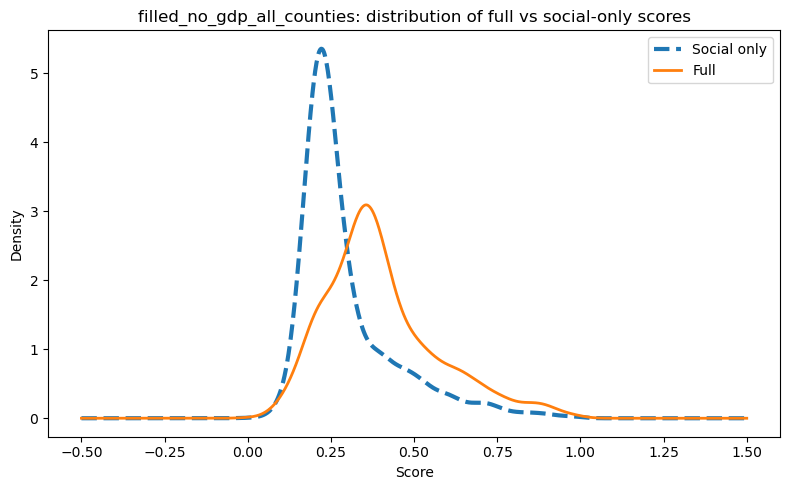

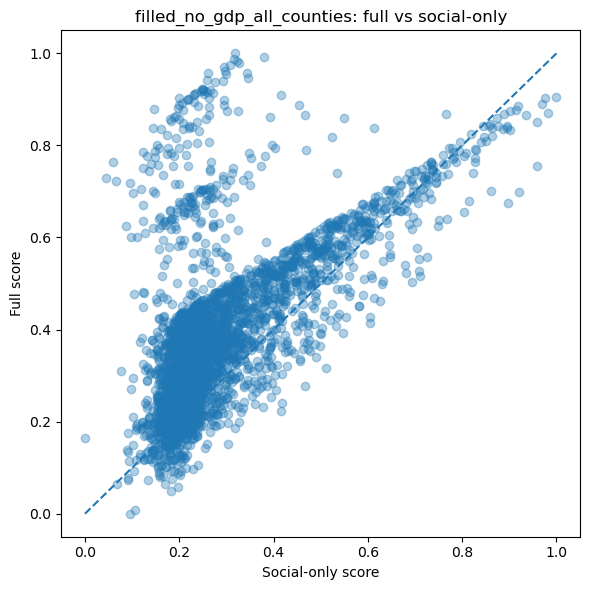

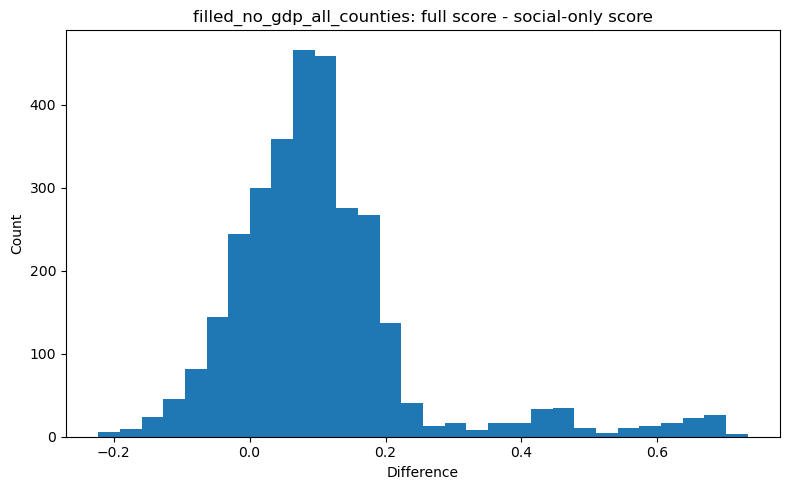

,n_counties,mean_social_score,mean_full_score,mean_diff_full_minus_social,median_diff_full_minus_social,mae,rmse,pearson_r,spearman_r,paired_t_stat,paired_t_pvalue,wilcoxon_stat,wilcoxon_pvalue,ks_stat,ks_pvalue
0,3099.0,0.294916,0.399822,0.104906,0.087022,0.122987,0.17651,0.610686,0.61135,41.133925,1.688516e-295,456250.0,0.0,0.412714,1.252309e-236



Interpretation:
- On average, full - social-only = 0.104906
- Pearson correlation = 0.611
- Spearman correlation = 0.611
- Paired t-test p-value = 1.689e-295
- Wilcoxon signed-rank p-value = 0.000e+00
- KS test p-value = 1.252e-236
- The paired t-test suggests the average full and social-only scores are statistically different.
- The Wilcoxon test suggests the median paired difference is statistically different from zero.
- The KS test suggests the two score distributions differ overall.
- Full and social-only scores are related, but meaningfully different.

Top 10 counties where full score is much higher than social-only:


,GEOID,county_name,social_score,full_score,diff,abs_diff
1762,35011,"De Baca, New Mexico",0.146636,0.879748,0.733112,0.733112
1778,35041,"Roosevelt, New Mexico",0.199267,0.903161,0.703894,0.703894
1767,35021,"Harding, New Mexico",0.060029,0.763327,0.703298,0.703298
2675,48389,"Reeves, Texas",0.260348,0.957983,0.697636,0.697636
1776,35037,"Quay, New Mexico",0.144488,0.837223,0.692735,0.692735
2633,48305,"Lynn, Texas",0.198707,0.886826,0.688119,0.688119
2521,48079,"Cochran, Texas",0.206130,0.892127,0.685997,0.685997
2603,48243,"Jeff Davis, Texas",0.044142,0.729194,0.685051,0.685051
1769,35025,"Lea, New Mexico",0.257920,0.941984,0.684065,0.684065
1766,35019,"Guadalupe, New Mexico",0.198299,0.880363,0.682065,0.682065


Top 10 counties where full score is lower than social-only:


,GEOID,county_name,social_score,full_score,diff,abs_diff
2898,51730,"Petersburg City, Virginia",0.921372,0.698554,-0.222818,0.222818
1169,24033,"Prince Georges, Maryland",0.896656,0.674968,-0.221688,0.221688
386,13063,"Clayton, Georgia",0.958551,0.756055,-0.202497,0.202497
2927,53033,"King, Washington",0.512271,0.316779,-0.195492,0.195492
192,06075,"San Francisco, California",0.711276,0.516047,-0.195229,0.195229
1750,34031,"Passaic, New Jersey",0.415085,0.222988,-0.192097,0.192097
2941,53061,"Snohomish, Washington",0.466206,0.276516,-0.189690,0.189690
2894,51690,"Martinsville City, Virginia",0.604183,0.414718,-0.189465,0.189465
1829,36081,"Queens, New York",0.692849,0.503834,-0.189014,0.189014
403,13097,"Douglas, Georgia",0.708718,0.527033,-0.181685,0.181685


In [316]:
# Difference between full and social-only scores:
# graphs + statistical tests in one cell

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("scipy not available; t-test / Wilcoxon / KS tests will be skipped.")

# Choose scenario here
scenario_name = "filled_no_gdp_all_counties"   # or "filled_with_gdp", etc.
df_test = scenarios_final[scenario_name][["GEOID", "county_name", "social_score", "full_score"]].copy()

# safety: one row per county
df_test = df_test.drop_duplicates("GEOID").dropna(subset=["social_score", "full_score"]).copy()

# paired difference
df_test["diff"] = df_test["full_score"] - df_test["social_score"]
df_test["abs_diff"] = df_test["diff"].abs()

print(f"Scenario: {scenario_name}")
print(f"N counties: {len(df_test)}")

# Graph 1: score distributions
fig, ax = plt.subplots(figsize=(8, 5))
df_test["social_score"].plot(kind="kde", ax=ax, label="Social only", linestyle="--", linewidth=3)
df_test["full_score"].plot(kind="kde", ax=ax, label="Full", linewidth=2)
ax.set_title(f"{scenario_name}: distribution of full vs social-only scores")
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Graph 2: scatter
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_test["social_score"], df_test["full_score"], alpha=0.35)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title(f"{scenario_name}: full vs social-only")
ax.set_xlabel("Social-only score")
ax.set_ylabel("Full score")
plt.tight_layout()
plt.show()

# Graph 3: histogram of paired differences
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_test["diff"], bins=30)
ax.set_title(f"{scenario_name}: full score - social-only score")
ax.set_xlabel("Difference")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Summary stats
summary = pd.Series({
    "n_counties": len(df_test),
    "mean_social_score": df_test["social_score"].mean(),
    "mean_full_score": df_test["full_score"].mean(),
    "mean_diff_full_minus_social": df_test["diff"].mean(),
    "median_diff_full_minus_social": df_test["diff"].median(),
    "mae": df_test["abs_diff"].mean(),
    "rmse": np.sqrt((df_test["diff"] ** 2).mean()),
    "pearson_r": df_test["social_score"].corr(df_test["full_score"], method="pearson"),
    "spearman_r": df_test["social_score"].corr(df_test["full_score"], method="spearman"),
})

# Statistical tests
test_results = {}

if SCIPY_AVAILABLE and len(df_test) > 1:
    # Paired t-test: do average full and social scores differ?
    t_res = stats.ttest_rel(df_test["full_score"], df_test["social_score"], nan_policy="omit")
    test_results["paired_t_stat"] = t_res.statistic
    test_results["paired_t_pvalue"] = t_res.pvalue

    # Wilcoxon signed-rank: nonparametric paired test
    try:
        w_res = stats.wilcoxon(df_test["full_score"], df_test["social_score"])
        test_results["wilcoxon_stat"] = w_res.statistic
        test_results["wilcoxon_pvalue"] = w_res.pvalue
    except Exception:
        test_results["wilcoxon_stat"] = np.nan
        test_results["wilcoxon_pvalue"] = np.nan

    # KS test: do the overall distributions differ?
    ks_res = stats.ks_2samp(df_test["full_score"], df_test["social_score"])
    test_results["ks_stat"] = ks_res.statistic
    test_results["ks_pvalue"] = ks_res.pvalue
else:
    test_results["paired_t_stat"] = np.nan
    test_results["paired_t_pvalue"] = np.nan
    test_results["wilcoxon_stat"] = np.nan
    test_results["wilcoxon_pvalue"] = np.nan
    test_results["ks_stat"] = np.nan
    test_results["ks_pvalue"] = np.nan

summary_df = pd.DataFrame([summary.to_dict() | test_results])
display(summary_df)

# Clear interpretation
mean_diff = summary["mean_diff_full_minus_social"]
pearson_r = summary["pearson_r"]
spearman_r = summary["spearman_r"]
p_t = test_results["paired_t_pvalue"]
p_w = test_results["wilcoxon_pvalue"]
p_ks = test_results["ks_pvalue"]

print("\nInterpretation:")
print(f"- On average, full - social-only = {mean_diff:.6f}")
print(f"- Pearson correlation = {pearson_r:.3f}")
print(f"- Spearman correlation = {spearman_r:.3f}")

if SCIPY_AVAILABLE:
    print(f"- Paired t-test p-value = {p_t:.3e}")
    print(f"- Wilcoxon signed-rank p-value = {p_w:.3e}" if pd.notna(p_w) else "- Wilcoxon test unavailable")
    print(f"- KS test p-value = {p_ks:.3e}")

    if pd.notna(p_t) and p_t < 0.05:
        print("- The paired t-test suggests the average full and social-only scores are statistically different.")
    else:
        print("- The paired t-test does not show a statistically significant average difference.")

    if pd.notna(p_w) and p_w < 0.05:
        print("- The Wilcoxon test suggests the median paired difference is statistically different from zero.")
    else:
        print("- The Wilcoxon test does not show a statistically significant median paired difference.")

    if pd.notna(p_ks) and p_ks < 0.05:
        print("- The KS test suggests the two score distributions differ overall.")
    else:
        print("- The KS test does not show a statistically significant distributional difference.")

if pearson_r > 0.9 and spearman_r > 0.9:
    print("- Full and social-only scores are extremely similar.")
elif pearson_r > 0.7 and spearman_r > 0.7:
    print("- Full and social-only scores are fairly similar, but not identical.")
else:
    print("- Full and social-only scores are related, but meaningfully different.")

# Most affected counties
print("\nTop 10 counties where full score is much higher than social-only:")
display(df_test.sort_values("diff", ascending=False).head(10))

print("Top 10 counties where full score is lower than social-only:")
display(df_test.sort_values("diff", ascending=True).head(10))